# **Installation**

In [1]:
!pip install -q lightgbm catboost imbalanced-learn xgboost scikit-learn pandas numpy
!pip install ipython-autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.4 MB/s eta 0:00:00


# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import uniform

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (make_scorer, accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix, balanced_accuracy_score)
from imblearn.metrics import geometric_mean_score
from sklearn.model_selection import KFold
from imblearn.over_sampling import ADASYN
import time
from scipy.stats import uniform
from sklearn.decomposition import PCA

# **Load Dataset**

In [3]:
df = pd.read_csv('/content/INCART 2-lead Arrhythmia Database.csv')

# **Data Preprocessing**

In [4]:
# Drop Leakage Feature
if 'record' in df.columns:
    df.drop('record', axis=1, inplace=True)

# Handle Null Values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df=df[df['type'] != 'Q']

# 4. Encode Target
df['type'] = df['type'].map({'F': 0, 'N': 1, 'SVEB': 2, 'VEB': 3})

# Split Features & Target
X = df.drop('type', axis=1)
y = df['type']
feature_names = X.columns

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **Scaling**


In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# **Sampling Technique**

In [6]:
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_s, y_train)

In [7]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_ad)
X_test_pca = pca.transform(X_test_s)

In [8]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
shap.initjs()
feature_names_pca = [f"PCA_{i+1}" for i in range(X_train_pca.shape[1])]
X_sample = pd.DataFrame(shap.sample(X_train_pca, 500), columns=feature_names_pca)

# **GBM**

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
#  Model base initialize
model = HistGradientBoostingClassifier(random_state=42)

# Parameter distribution setup
params = {
  "max_iter": [50, 100],
  "learning_rate": [0.1, 0.2]
}

#  Randomized Search execution
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# Training
rs.fit(X_train_pca, y_train_ad)

# Best model extract
final_gbm_model = rs.best_estimator_

print(f"Best Parameters: {rs.best_params_}")

Best Parameters: {'max_iter': 100, 'learning_rate': 0.1}


GBM SHAP EXPALANATION...
 GBM - Global Feature Importance (Bar)


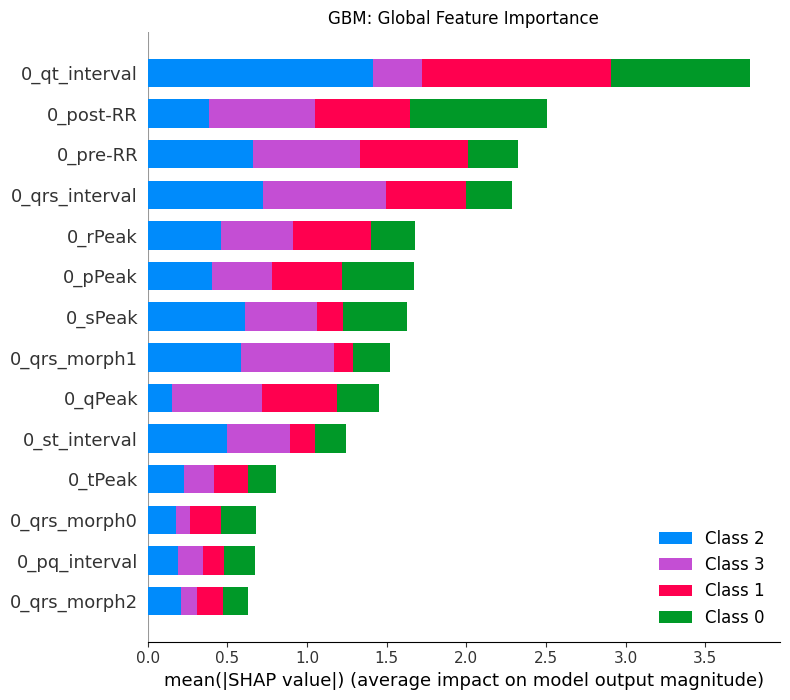

GBM - Detailed Summary Plot (Dot)


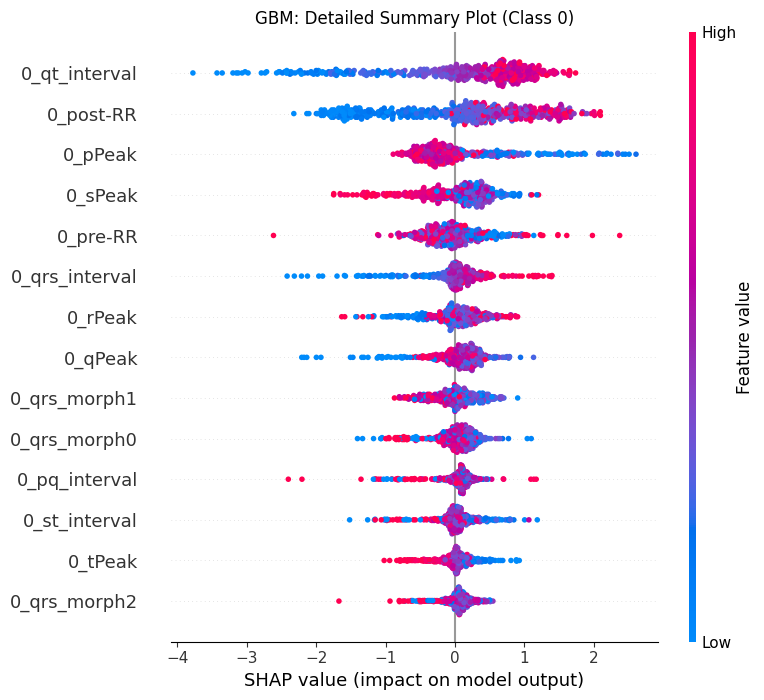

GBM - Dependence Plot


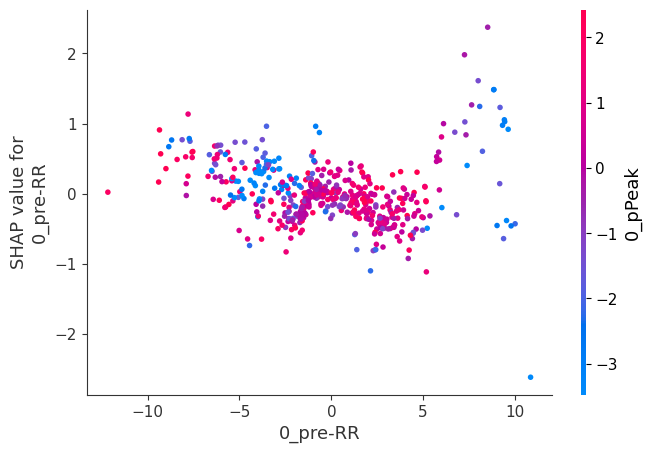

GBM - Local Explanation (Force Plot)
   ➤ Class 0 Force Plot:


   ➤ Class 1 Force Plot:


   ➤ Class 2 Force Plot:


   ➤ Class 3 Force Plot:


In [25]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

shap.initjs()
print("GBM SHAP EXPALANATION...")

all_real_features = list(X_train.columns)

num_pca_features = X_train_pca.shape[1]
real_feature_names = all_real_features[:num_pca_features]

X_sample = pd.DataFrame(shap.sample(X_train_pca, 500), columns=real_feature_names)

explainer_gbm = shap.TreeExplainer(final_gbm_model)
shap_values_gbm = explainer_gbm.shap_values(X_sample)
expected_value_gbm = explainer_gbm.expected_value

if isinstance(shap_values_gbm, list):
    sv_gbm_c0 = shap_values_gbm[0]
    num_classes = len(shap_values_gbm)
elif len(np.array(shap_values_gbm).shape) == 3:
    sv_gbm_c0 = shap_values_gbm[:, :, 0]
    num_classes = shap_values_gbm.shape[2]
else:
    sv_gbm_c0 = shap_values_gbm
    num_classes = 1

# ---------------------------------------------------------
# Global Feature Importance (Stacked Bar Plot)
# ---------------------------------------------------------
print(" GBM - Global Feature Importance (Bar)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gbm, X_sample, feature_names=real_feature_names, plot_type="bar", show=False)
plt.title("GBM: Global Feature Importance")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
# Detailed Summary Plot (Dot Plot - Class 0)
# ---------------------------------------------------------
print("GBM - Detailed Summary Plot (Dot)")
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_gbm_c0, X_sample, feature_names=real_feature_names, plot_type="dot", show=False)
plt.title("GBM: Detailed Summary Plot (Class 0)")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
# Dependence Plot
# ---------------------------------------------------------
print("GBM - Dependence Plot")
shap.dependence_plot(real_feature_names[0], sv_gbm_c0, X_sample, feature_names=real_feature_names, interaction_index="auto")

# ---------------------------------------------------------
# Local Explanation (Force Plot - Instance 0)
# ---------------------------------------------------------
print("GBM - Local Explanation (Force Plot)")
if num_classes > 1:
    for i in range(num_classes):
        print(f"   ➤ Class {i} Force Plot:")
        exp_val = expected_value_gbm[i] if isinstance(expected_value_gbm, (list, np.ndarray)) else expected_value_gbm

        if isinstance(shap_values_gbm, list):
            sv_instance = shap_values_gbm[i][0]
        else:
            sv_instance = shap_values_gbm[0, :, i]

        display(shap.force_plot(exp_val, sv_instance, X_sample.iloc[0], feature_names=real_feature_names))
else:
    display(shap.force_plot(expected_value_gbm, shap_values_gbm[0], X_sample.iloc[0], feature_names=real_feature_names))

# **XGboost**

In [15]:
from xgboost import XGBClassifier
#  Model base initialize
model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42, tree_method='hist')

# Parameter distribution setup
params = {
"n_estimators": [50, 100],
"learning_rate": [0.1, 0.2],
"max_depth": [3, 5, 6],
"subsample": [0.8],
"colsample_bytree":[0.8]
}

#  Randomized Search execution
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# Training
rs.fit(X_train_pca, y_train_ad)

# Best model extract
final_xg_model = rs.best_estimator_

print(f"Best Parameters: {rs.best_params_}")

Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


XGBoost SHAP EXPLANATION...
 XGBoost - Global Feature Importance (Bar)


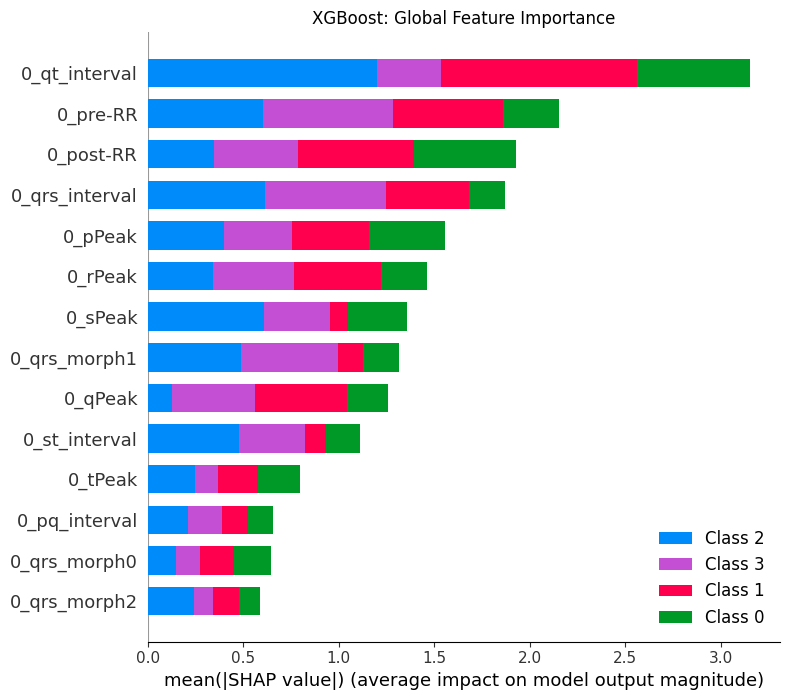

XGBoost - Detailed Summary Plot (Dot)


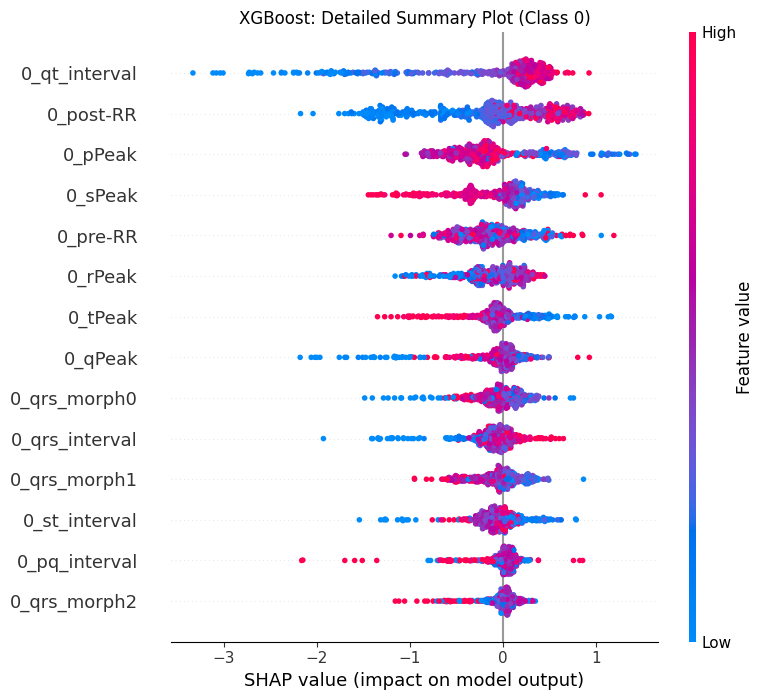

XGBoost - Dependence Plot


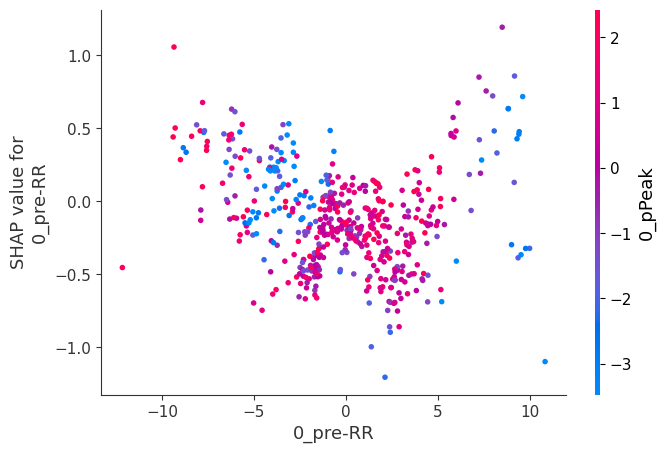

XGBoost - Local Explanation (Force Plot)
   ➤ Class 0 Force Plot:


   ➤ Class 1 Force Plot:


   ➤ Class 2 Force Plot:


   ➤ Class 3 Force Plot:


In [24]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

shap.initjs()
print("XGBoost SHAP EXPLANATION...")

all_real_features = list(X_train.columns)

num_pca_features = X_train_pca.shape[1]
real_feature_names = all_real_features[:num_pca_features]

X_sample = pd.DataFrame(shap.sample(X_train_pca, 500), columns=real_feature_names)


explainer_xgb = shap.TreeExplainer(final_xg_model)
shap_values_xgb = explainer_xgb.shap_values(X_sample)
expected_value_xgb = explainer_xgb.expected_value

if isinstance(shap_values_xgb, list):
    sv_xgb_c0 = shap_values_xgb[0]
    num_classes = len(shap_values_xgb)
elif len(np.array(shap_values_xgb).shape) == 3:
    sv_xgb_c0 = shap_values_xgb[:, :, 0]
    num_classes = shap_values_xgb.shape[2]
else:
    sv_xgb_c0 = shap_values_xgb
    num_classes = 1

# ---------------------------------------------------------
# Global Feature Importance ( Bar Plot)
# ---------------------------------------------------------
print(" XGBoost - Global Feature Importance (Bar)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_sample, feature_names=real_feature_names, plot_type="bar", show=False)
plt.title("XGBoost: Global Feature Importance")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
# Detailed Summary Plot (Standard Dot Plot - Class 0)
# ---------------------------------------------------------
print("XGBoost - Detailed Summary Plot (Dot)")
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_xgb_c0, X_sample, feature_names=real_feature_names, plot_type="dot", show=False)
plt.title("XGBoost: Detailed Summary Plot (Class 0)")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
# Dependence Plot
# ---------------------------------------------------------
print("XGBoost - Dependence Plot")
shap.dependence_plot(real_feature_names[0], sv_xgb_c0, X_sample, feature_names=real_feature_names, interaction_index="auto")

# ---------------------------------------------------------
# Local Explanation (Force Plot )
# ---------------------------------------------------------
print("XGBoost - Local Explanation (Force Plot)")
if num_classes > 1:
    for i in range(num_classes):
        print(f"   ➤ Class {i} Force Plot:")
        exp_val = expected_value_xgb[i] if isinstance(expected_value_xgb, (list, np.ndarray)) else expected_value_xgb

        if isinstance(shap_values_xgb, list):
            sv_instance = shap_values_xgb[i][0]
        else:
            sv_instance = shap_values_xgb[0, :, i]

        display(shap.force_plot(exp_val, sv_instance, X_sample.iloc[0], feature_names=real_feature_names))
else:
    display(shap.force_plot(expected_value_xgb, shap_values_xgb[0], X_sample.iloc[0], feature_names=real_feature_names))

# **LightGBM**

In [19]:
from lightgbm import LGBMClassifier
#  Model base initialize
model = LGBMClassifier(random_state=42,verbosity=-1)

# Parameter distribution setup
params = {
"n_estimators": [100, 150],
"learning_rate": [0.05, 0.1],
"num_leaves": [31, 40],
"boosting_type": ['gbdt']
}

#  Randomized Search execution
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# Training
rs.fit(X_train_pca, y_train_ad)

# Best model extract
final_lgbm_model = rs.best_estimator_

print(f"Best Parameters: {rs.best_params_}")

Best Parameters: {'num_leaves': 40, 'n_estimators': 100, 'learning_rate': 0.1, 'boosting_type': 'gbdt'}


LightGBM SHAP EXPLANATION...
LightGBM - Global Feature Importance (Bar)


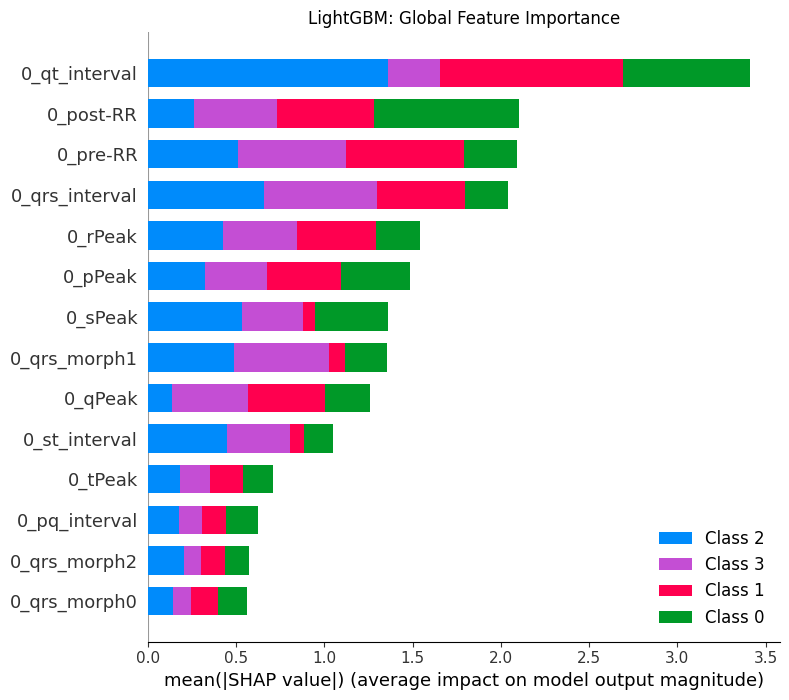

LightGBM - Detailed Summary Plot (Dot)


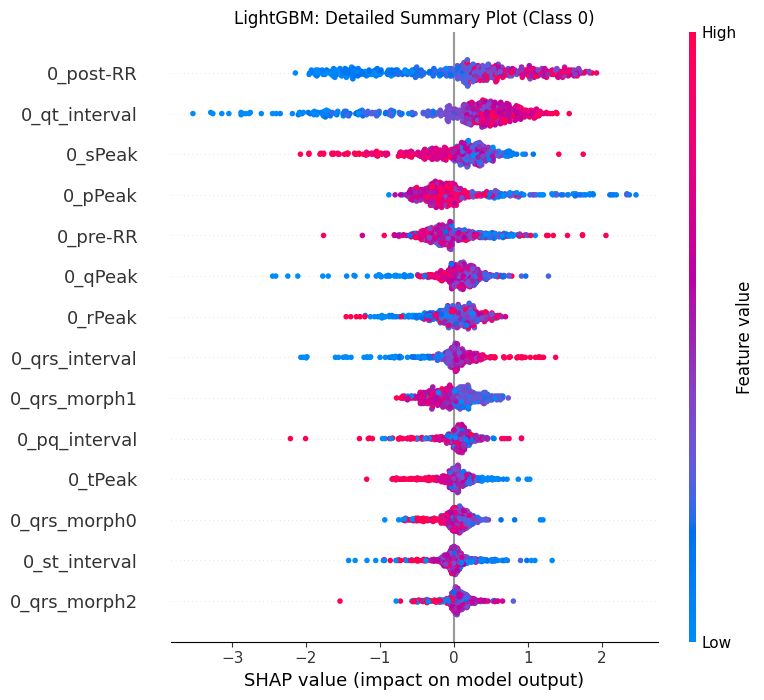

LightGBM - Dependence Plot


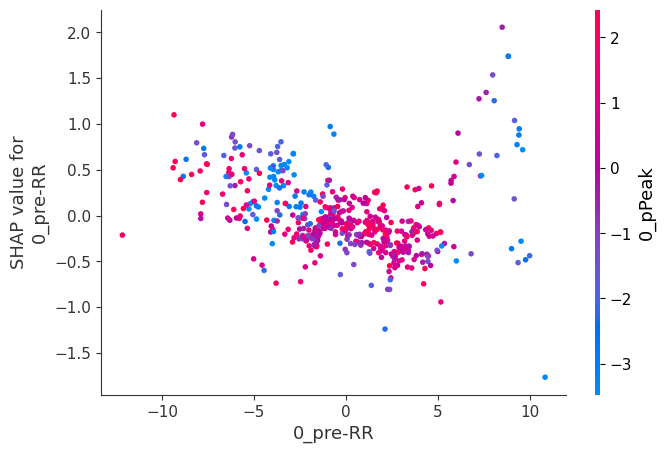

LightGBM - Local Explanation (Force Plot)
   ➤ Class 0 Force Plot:


   ➤ Class 1 Force Plot:


   ➤ Class 2 Force Plot:


   ➤ Class 3 Force Plot:


In [23]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

shap.initjs()
print("LightGBM SHAP EXPLANATION...")

all_real_features = list(X_train.columns)

num_pca_features = X_train_pca.shape[1]
real_feature_names = all_real_features[:num_pca_features]

X_sample = pd.DataFrame(shap.sample(X_train_pca, 500), columns=real_feature_names)

explainer_lgbm = shap.TreeExplainer(final_lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_sample)
expected_value_lgbm = explainer_lgbm.expected_value

if isinstance(shap_values_lgbm, list):
    sv_lgbm_c0 = shap_values_lgbm[0]
    num_classes = len(shap_values_lgbm)
elif len(np.array(shap_values_lgbm).shape) == 3:
    sv_lgbm_c0 = shap_values_lgbm[:, :, 0]
    num_classes = shap_values_lgbm.shape[2]
else:
    sv_lgbm_c0 = shap_values_lgbm
    num_classes = 1

# ---------------------------------------------------------
# Global Feature Importance (Bar Plot)
# ---------------------------------------------------------
print("LightGBM - Global Feature Importance (Bar)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lgbm, X_sample, feature_names=real_feature_names, plot_type="bar", show=False)
plt.title("LightGBM: Global Feature Importance")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
# Detailed Summary Plot (Dot Plot - Class 0 )
# ---------------------------------------------------------
print("LightGBM - Detailed Summary Plot (Dot)")
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_lgbm_c0, X_sample, feature_names=real_feature_names, plot_type="dot", show=False)
plt.title("LightGBM: Detailed Summary Plot (Class 0)")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
#  Dependence Plot
# ---------------------------------------------------------
print("LightGBM - Dependence Plot")
shap.dependence_plot(real_feature_names[0], sv_lgbm_c0, X_sample, feature_names=real_feature_names, interaction_index="auto")

# ---------------------------------------------------------
# Local Explanation (Force Plot)
# ---------------------------------------------------------
print("LightGBM - Local Explanation (Force Plot)")
if num_classes > 1:
    for i in range(num_classes):
        print(f"   ➤ Class {i} Force Plot:")
        exp_val = expected_value_gbm[i] if isinstance(expected_value_lgbm, (list, np.ndarray)) else expected_value_lgbm

        if isinstance(shap_values_lgbm, list):
            sv_instance = shap_values_lgbm[i][0]
        else:
            sv_instance = shap_values_lgbm[0, :, i]

        display(shap.force_plot(exp_val, sv_instance, X_sample.iloc[0], feature_names=real_feature_names))
else:
    display(shap.force_plot(expected_value_lgbm, shap_values_lgbm[0], X_sample.iloc[0], feature_names=real_feature_names))

# **Catboost**

In [21]:
from catboost import CatBoostClassifier
#  Model base initialize
model = CatBoostClassifier(random_state=42,verbose=0, thread_count=-1, loss_function='MultiClass')

# Parameter distribution setup
params = {
"iterations": [100, 200],
"learning_rate": [0.05, 0.1],
"depth": [4, 6]
}

#  Randomized Search execution
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# Training
rs.fit(X_train_pca, y_train_ad)

# Best model extract
final_cat_model = rs.best_estimator_

print(f"Best Parameters: {rs.best_params_}")

Best Parameters: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}


CatBoost SHAP EXPLANATION...
CatBoost - Global Feature Importance (Bar)


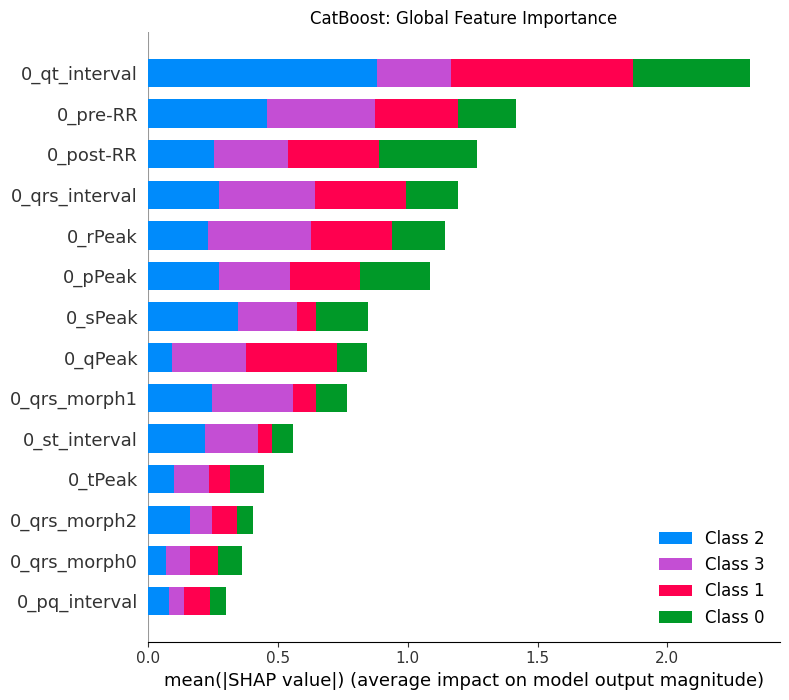

CatBoost - Detailed Summary Plot (Dot)


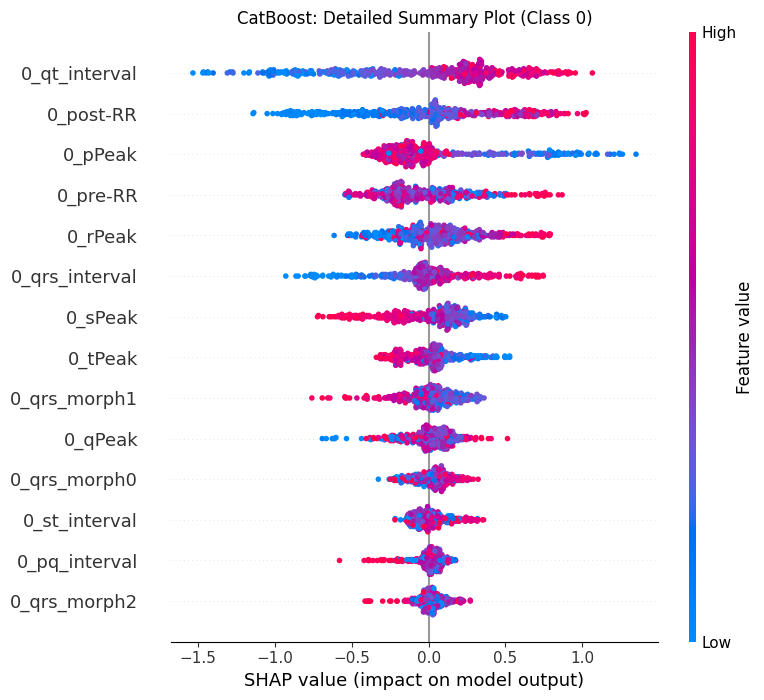

CatBoost - Dependence Plot


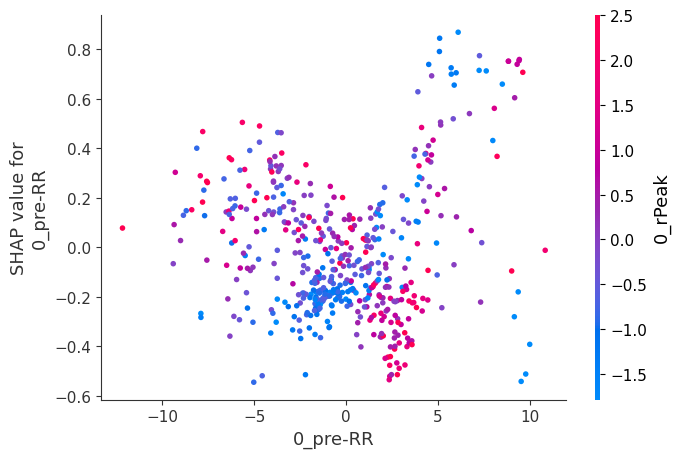

CatBoost - Local Explanation (Force Plot)
   ➤ Class 0 Force Plot:


   ➤ Class 1 Force Plot:


   ➤ Class 2 Force Plot:


   ➤ Class 3 Force Plot:


In [22]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

shap.initjs()
print("CatBoost SHAP EXPLANATION...")

all_real_features = list(X_train.columns)

num_pca_features = X_train_pca.shape[1]
real_feature_names = all_real_features[:num_pca_features]

X_sample = pd.DataFrame(shap.sample(X_train_pca, 500), columns=real_feature_names)

explainer_cat = shap.TreeExplainer(final_cat_model)
shap_values_cat = explainer_cat.shap_values(X_sample)
expected_value_cat = explainer_cat.expected_value

if isinstance(shap_values_cat, list):
    sv_cat_c0 = shap_values_cat[0]
    num_classes = len(shap_values_cat)
elif len(np.array(shap_values_cat).shape) == 3:
    sv_cat_c0 = shap_values_cat[:, :, 0]
    num_classes = shap_values_cat.shape[2]
else:
    sv_cat_c0 = shap_values_cat
    num_classes = 1

# ---------------------------------------------------------
# Global Feature Importance (Bar Plot)
# ---------------------------------------------------------
print("CatBoost - Global Feature Importance (Bar)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cat, X_sample, feature_names=real_feature_names, plot_type="bar", show=False)
plt.title("CatBoost: Global Feature Importance")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
# Detailed Summary Plot (Dot Plot - Class 0)
# ---------------------------------------------------------
print("CatBoost - Detailed Summary Plot (Dot)")
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_cat_c0, X_sample, feature_names=real_feature_names, plot_type="dot", show=False)
plt.title("CatBoost: Detailed Summary Plot (Class 0)")
plt.tight_layout()
plt.show(); plt.close()

# ---------------------------------------------------------
#  Dependence Plot
# ---------------------------------------------------------
print("CatBoost - Dependence Plot")
shap.dependence_plot(real_feature_names[0], sv_cat_c0, X_sample, feature_names=real_feature_names, interaction_index="auto")

# ---------------------------------------------------------
# Local Explanation (Force Plot )
# ---------------------------------------------------------
print("CatBoost - Local Explanation (Force Plot)")
if num_classes > 1:
    for i in range(num_classes):
        print(f"   ➤ Class {i} Force Plot:")
        exp_val = expected_value_cat[i] if isinstance(expected_value_cat, (list, np.ndarray)) else expected_value_cat

        if isinstance(shap_values_cat, list):
            sv_instance = shap_values_cat[i][0]
        else:
            sv_instance = shap_values_cat[0, :, i]

        display(shap.force_plot(exp_val, sv_instance, X_sample.iloc[0], feature_names=real_feature_names))
else:
    display(shap.force_plot(expected_value_cat, shap_values_cat[0], X_sample.iloc[0], feature_names=real_feature_names))